In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from typing import Union, Dict, Tuple
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
# %matplotlib inline

# Table of Contents
- [Feature Description](#Feature-Description)
- [Baseline CatBoost Model](#Baseline-CatBoost-Model)
- [Baseline Catboost Model lag features](#Baseline-Catboost-Model-lag-features)
- [Hyperparameter Tuning (Optuna)](#Hyperparameter-Tuning-Optuna)
- [Classical Forecasting Methods (SARIMAX)](#Classical-Forecasting-Methods-SARIMAX)
- [Conclusions](#Conclusions)

# Feature Description

In [32]:
# Loading the data
data = pd.read_parquet('../data/01_raw/bike_data_train.parquet')
data.head(20)

,datetime,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt
0,2011-01-01 00:00:00,1,0,0,6,1,0.24,0.81,0.0000,16
1,2011-01-01 01:00:00,1,1,0,6,1,0.22,0.80,0.0000,40
2,2011-01-01 02:00:00,1,2,0,6,1,0.22,0.80,0.0000,32
3,2011-01-01 03:00:00,1,3,0,6,1,0.24,0.75,0.0000,13
4,2011-01-01 04:00:00,1,4,0,6,1,0.24,0.75,0.0000,1
5,2011-01-01 05:00:00,1,5,0,6,2,0.24,0.75,0.0896,1
6,2011-01-01 06:00:00,1,6,0,6,1,0.22,0.80,0.0000,2
7,2011-01-01 07:00:00,1,7,0,6,1,0.20,0.86,0.0000,3
8,2011-01-01 08:00:00,1,8,0,6,1,0.24,0.75,0.0000,8
9,2011-01-01 09:00:00,1,9,0,6,1,0.32,0.76,0.0000,14


- datetime - hourly date + date

- season:
    -  1 = winter, 2 = spring, 3 = summer, 4 = fall

- h - hour of the day

- holiday - whether the day is considered a holiday

- weekday - day number of the week

- weathersit
   - 1: Clear & Partly cloudy, Partly cloudy
   - 2: Mist + Cloudy
   - 3: Light Snow, Light Rain
   - 4: Heavy Rain, Snow
 
- temp - temperature in Celsius
- humidity - relative humidity
- windspeed - wind speed
- count - number of total rentals

In [33]:
data.columns

Index(['datetime', 'season', 'hr', 'holiday', 'weekday', 'weathersit', 'temp',
       'hum', 'windspeed', 'cnt'],
      dtype='object')

In [34]:
drop_cols = ['datetime']

In [35]:
data = data.drop(columns=drop_cols)

In [36]:
data.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt
0,1,0,0,6,1,0.24,0.81,0.0,16
1,1,1,0,6,1,0.22,0.80,0.0,40
2,1,2,0,6,1,0.22,0.80,0.0,32


# Baseline CatBoost Model

We will use CatBoost with raw features as a model.

Then, we will add features and try other algorithms to see how big the improvement is.

For the metrics, we will use:
- MAPE
- MAE
- RMSE

In [37]:
def compute_metrics(
    y_true: Union[np.ndarray, list], 
    y_pred: Union[np.ndarray, list]
) -> Dict[str, float]:
    """
    Compute evaluation metrics between true and predicted values.

    Metrics returned:
    - MAPE: Mean Absolute Percentage Error (in %)
    - MAE: Mean Absolute Error
    - RMSE: Root Mean Squared Error

    Parameters:
    ----------
    y_true : array-like
        Ground truth values.
    y_pred : array-like
        Predicted values.

    Returns:
    -------
    dict
        Dictionary with keys 'MAPE', 'MAE', and 'RMSE' and their float values.
    """
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = np.mean(np.abs((y_true - y_pred) / y_true + 1e-8)) * 100

    return {
        'MAE': float(round(mae, 2)),
        'RMSE': float(round(rmse, 2)),
        'MAPE': float(round(mape, 2)),
    }

In [38]:
def prepare_dataset(
    df: pd.DataFrame, 
    train_fraction: float = 0.8
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Splits a DataFrame into training and testing sets for features and target.

    Parameters:
    ----------
    df : pd.DataFrame
        The input DataFrame that must contain a 'target' column.
    train_fraction : float, optional (default=0.8)
        The fraction of data to use for training (between 0 and 1).

    Returns:
    -------
    x_train : pd.DataFrame
        Training features.
    x_test : pd.DataFrame
        Testing features.
    y_train : pd.Series
        Training target values.
    y_test : pd.Series
        Testing target values.
    """
    feats = [col for col in df.columns if col != 'target']
    x, y = df[feats], df['target']
    train_size = int(train_fraction * df.shape[0])
    x_train, x_test = x[:train_size], x[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    return x_train, x_test, y_train, y_test

### Target definition

In [39]:
df = data.copy()

In [40]:
df['target'] = df['cnt'].shift(-1).ffill()
df.drop(columns=['cnt'], inplace=True)

In [41]:
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,target
0,1,0,0,6,1,0.24,0.81,0.0,40.0
1,1,1,0,6,1,0.22,0.80,0.0,32.0
2,1,2,0,6,1,0.22,0.80,0.0,13.0


### Fitting the model

In [42]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [43]:
params = {
    'learning_rate': 0.2,
    'depth': 6,
    'l2_leaf_reg': 1,
    'iterations': 500,
    'loss_function': 'RMSE',
    'verbose': 0
}

np.random.seed(42)
model = CatBoostRegressor(**params, random_seed=42)

# Tuning with early stopping
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

### Baseline prediction

In [44]:
y_pred = model.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 85.27, 'RMSE': 116.06, 'MAPE': 43.99}

Text(0.5, 1.0, 'Rented Bike Count, 1-h Forecast, Baseline')

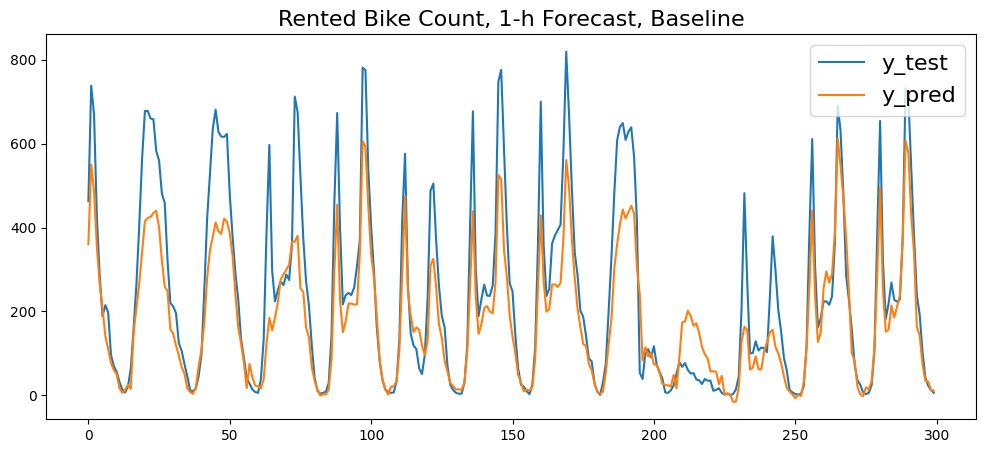

In [45]:
n = 300
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=16)
plt.title('Rented Bike Count, 1-h Forecast, Baseline', fontsize=16)

We see that the model is not really good and does not capture the important spike area where demand is the highest.

Let's add some basic lagged features to see if this helps.

# Baseline Catboost Model lag features

A good idea is to add the lagged values of the target because we assume it's goona be available by the time we make the predictions for the next hour.

To understand how many lagged features we need, let's compute autocorrelation for the target.

In [46]:
df = data.copy()
df['target'] = df['cnt'].shift(-1).ffill()
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,target
0,1,0,0,6,1,0.24,0.81,0.0,16,40.0
1,1,1,0,6,1,0.22,0.80,0.0,40,32.0
2,1,2,0,6,1,0.22,0.80,0.0,32,13.0


In [47]:
# Let's compute autocorrelation
for lag in range(1, 25):
    print(f"Lag {lag}: {df['target'].autocorr(lag=lag):.3f}")

Lag 1: 0.845
Lag 2: 0.597
Lag 3: 0.407
Lag 4: 0.274
Lag 5: 0.146
Lag 6: 0.010
Lag 7: -0.094
Lag 8: -0.114
Lag 9: -0.058
Lag 10: -0.049
Lag 11: -0.100
Lag 12: -0.131
Lag 13: -0.105
Lag 14: -0.057
Lag 15: -0.058
Lag 16: -0.094
Lag 17: -0.065
Lag 18: 0.033
Lag 19: 0.153
Lag 20: 0.262
Lag 21: 0.371
Lag 22: 0.520
Lag 23: 0.705
Lag 24: 0.809


#### Target Lags

The 'cnt' column is alread 1 lag behind the target, so we need to make shifts of the 'cnt' column from 1 to 2 and from 22 to 23.

In [48]:
# Add first 2 lags
for i in range(1, 3):
    df[f'cnt_lag_{i}'] = df['cnt'].shift(i).bfill()

# Add last 2 lags
for i in range(22, 24):
    df[f'cnt_lag_{i}'] = df['cnt'].shift(i).bfill()

#### Other Feature Lags

In [49]:
lag_feats = ['hr', 'temp', 'hum']

n = 3
for feat in lag_feats:
    for i in range(1, n+1):
        df[f'{feat}_lag_{i}'] = df[feat].shift(i).bfill()

In [50]:
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,target,...,cnt_lag_23,hr_lag_1,hr_lag_2,hr_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,hum_lag_1,hum_lag_2,hum_lag_3
0,1,0,0,6,1,0.24,0.81,0.0,16,40.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
1,1,1,0,6,1,0.22,0.80,0.0,40,32.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
2,1,2,0,6,1,0.22,0.80,0.0,32,13.0,...,16.0,1.0,0.0,0.0,0.22,0.24,0.24,0.80,0.81,0.81


## Training the Model with Lags

Let's see if new features help the model.

In [51]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [52]:
x_train.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,cnt_lag_1,...,cnt_lag_23,hr_lag_1,hr_lag_2,hr_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,hum_lag_1,hum_lag_2,hum_lag_3
0,1,0,0,6,1,0.24,0.81,0.0,16,16.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
1,1,1,0,6,1,0.22,0.80,0.0,40,16.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
2,1,2,0,6,1,0.22,0.80,0.0,32,40.0,...,16.0,1.0,0.0,0.0,0.22,0.24,0.24,0.80,0.81,0.81


In [53]:
best_params = {
    'learning_rate': 0.06050932772168376,
    'depth': 6,
    'l2_leaf_reg': 1.4634267036714088,
    'bagging_temperature': 0.27768283284999584,
    'random_strength': 0.1784658242263378,
    'min_data_in_leaf': 31,
    'iterations': 316,
    'loss_function': 'RMSE',
    'verbose': 0,
    'random_seed': 42
}

np.random.seed(42)
model = CatBoostRegressor(**params, random_seed=42)

# Tuning with early stopping
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

In [54]:
y_pred = model.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 38.75, 'RMSE': 61.29, 'MAPE': 24.67}

Text(0.5, 1.0, 'Rented Bike Count, 1-h Forecast, Model with Lags')

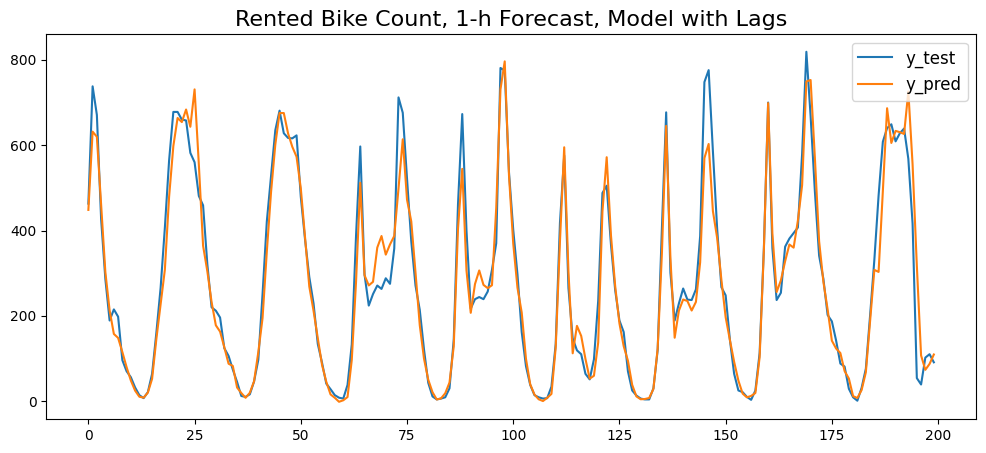

In [55]:
n = 200
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=12)
plt.title('Rented Bike Count, 1-h Forecast, Model with Lags', fontsize=16)

Now, the model seems ok, we can proceed with it and build the baseline pipeline.

In [32]:
# Save the model to experiments
model.save_model('../data/06_models/first_catboost_model.cbm')

# Hyperparameter Tuning (Optuna)

Tune CatBoost on the **lag-feature** dataset. We do not chase a single best score blindly: use Optuna's search **and** visualizations (timeline, history, param importances, EDF) to understand what matters and when to stop.

**Protocol**
- Chronological **train / valid / test** split (no shuffled CV)
- Optimize **validation MAE**; touch **test** only for the final winner
- TPE sampler + MedianPruner; fixed `random_seed=42`

In [26]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.metrics import mean_absolute_error

# Reuse lag-feature frame `df` from the section above (cnt/hr/temp/hum lags + target).
# Chronological split: 64% train / 16% valid / 20% test  (valid carved from first 80%).
TUNING_CFG = {
    "n_trials": 70,
    "train_fraction": 0.8,
    "valid_within_train": 0.2,  # last 20% of the train block -> valid
    "early_stopping_rounds": 30,
    "random_seed": 42,
}

feature_cols = [c for c in df.columns if c != "target"]
x = df[feature_cols].copy()
y = df["target"].copy()

n = len(df)
train_end = int(TUNING_CFG["train_fraction"] * n)
valid_start = int(train_end * (1 - TUNING_CFG["valid_within_train"]))

x_train, y_train = x.iloc[:valid_start], y.iloc[:valid_start]
x_valid, y_valid = x.iloc[valid_start:train_end], y.iloc[valid_start:train_end]
x_test, y_test = x.iloc[train_end:], y.iloc[train_end:]

print(
    f"train={len(x_train)}, valid={len(x_valid)}, test={len(x_test)} "
    f"(features={len(feature_cols)})"
)

train=8897, valid=2225, test=2781 (features=22)


In [27]:
def objective(trial: optuna.Trial) -> float:
    """Train CatBoost; return validation MAE (minimized)."""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-1, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "iterations": trial.suggest_int("iterations", 100, 500),
        "loss_function": "RMSE",
        "verbose": 0,
        "allow_writing_files": False,
        "random_seed": TUNING_CFG["random_seed"],
    }

    model = CatBoostRegressor(**params)
    model.fit(
        x_train,
        y_train,
        eval_set=(x_valid, y_valid),
        early_stopping_rounds=TUNING_CFG["early_stopping_rounds"],
        use_best_model=True,
    )

    pred = model.predict(x_valid)
    mae = float(mean_absolute_error(y_valid, pred))

    # Report for MedianPruner (single-step report is enough with early stopping).
    trial.report(mae, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return mae


study = optuna.create_study(
    direction="minimize",
    study_name="catboost_bike_demand",
    sampler=TPESampler(seed=TUNING_CFG["random_seed"]),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=0),
)

print("Study ready:", study.study_name)
print("Objective: minimize validation MAE")
print("Call study.optimize in the next cell.")

[I 2026-07-28 14:18:40,736] A new study created in memory with name: catboost_bike_demand


Study ready: catboost_bike_demand
Objective: minimize validation MAE
Call study.optimize in the next cell.


In [28]:
# Run the search (takes a few minutes depending on n_trials).
study.optimize(objective, n_trials=TUNING_CFG["n_trials"], show_progress_bar=True)

print("Best valid MAE:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 1. Best value: 33.8889:   3%|▎         | 2/70 [00:00<00:12,  5.48it/s]

[I 2026-07-28 14:19:08,929] Trial 0 finished with value: 35.82486701397538 and parameters: {'learning_rate': 0.03574712922600244, 'depth': 8, 'l2_leaf_reg': 2.9106359131330706, 'bagging_temperature': 0.5986584841970366, 'random_strength': 0.31203728088487304, 'min_data_in_leaf': 8, 'iterations': 123}. Best is trial 0 with value: 35.82486701397538.
[I 2026-07-28 14:19:09,102] Trial 1 finished with value: 33.888865383794304 and parameters: {'learning_rate': 0.19030368381735815, 'depth': 7, 'l2_leaf_reg': 2.6070247583707675, 'bagging_temperature': 0.020584494295802447, 'random_strength': 1.9398197043239886, 'min_data_in_leaf': 42, 'iterations': 185}. Best is trial 1 with value: 33.888865383794304.


Best trial: 1. Best value: 33.8889:   6%|▌         | 4/70 [00:00<00:12,  5.32it/s]

[I 2026-07-28 14:19:09,290] Trial 2 finished with value: 37.839407348230424 and parameters: {'learning_rate': 0.01855998084649058, 'depth': 4, 'l2_leaf_reg': 0.4059611610484306, 'bagging_temperature': 0.5247564316322378, 'random_strength': 0.8638900372842315, 'min_data_in_leaf': 15, 'iterations': 345}. Best is trial 1 with value: 33.888865383794304.
[I 2026-07-28 14:19:09,483] Trial 3 finished with value: 39.232519706208556 and parameters: {'learning_rate': 0.01607123851203988, 'depth': 5, 'l2_leaf_reg': 0.540410385464733, 'bagging_temperature': 0.45606998421703593, 'random_strength': 1.5703519227860272, 'min_data_in_leaf': 10, 'iterations': 306}. Best is trial 1 with value: 33.888865383794304.


Best trial: 5. Best value: 33.6488:   9%|▊         | 6/70 [00:00<00:09,  6.77it/s]

...

[I 2026-07-28 14:19:22,491] Trial 66 finished with value: 33.079574109206625 and parameters: {'learning_rate': 0.04823401796289407, 'depth': 6, 'l2_leaf_reg': 0.8322412461212806, 'bagging_temperature': 0.1696763666850856, 'random_strength': 0.41516807023912833, 'min_data_in_leaf': 28, 'iterations': 401}. Best is trial 49 with value: 32.21740368880783.


Best trial: 67. Best value: 32.1345:  99%|█████████▊| 69/70 [00:14<00:00,  5.03it/s]

[I 2026-07-28 14:19:22,700] Trial 67 finished with value: 32.134501149095435 and parameters: {'learning_rate': 0.06050932772168376, 'depth': 6, 'l2_leaf_reg': 1.4634267036714088, 'bagging_temperature': 0.27768283284999584, 'random_strength': 0.1784658242263378, 'min_data_in_leaf': 31, 'iterations': 316}. Best is trial 67 with value: 32.134501149095435.
[I 2026-07-28 14:19:22,897] Trial 68 finished with value: 32.494222096710345 and parameters: {'learning_rate': 0.05818168724955262, 'depth': 7, 'l2_leaf_reg': 1.2765521039332366, 'bagging_temperature': 0.24589138019733894, 'random_strength': 0.16956564091449355, 'min_data_in_leaf': 34, 'iterations': 294}. Best is trial 67 with value: 32.134501149095435.


Best trial: 67. Best value: 32.1345: 100%|██████████| 70/70 [00:14<00:00,  4.90it/s]

[I 2026-07-28 14:19:23,022] Trial 69 finished with value: 32.51337232242423 and parameters: {'learning_rate': 0.10850819935239964, 'depth': 7, 'l2_leaf_reg': 1.5973510441598764, 'bagging_temperature': 0.27508623244608404, 'random_strength': 0.10484033624549509, 'min_data_in_leaf': 35, 'iterations': 242}. Best is trial 67 with value: 32.134501149095435.
Best valid MAE: 32.134501149095435
Best params:
  learning_rate: 0.06050932772168376
  depth: 6
  l2_leaf_reg: 1.4634267036714088
  bagging_temperature: 0.27768283284999584
  random_strength: 0.1784658242263378
  min_data_in_leaf: 31
  iterations: 316


## Optuna visualizations

Interpret the search before locking parameters:

| Plot | What to look for |
|------|------------------|
| **Timeline** | Failed / very slow trials → tighten search space |
| **Optimization history** | Plateau → more trials won't help much |
| **Param importances** | Which knobs drive MAE → focus a 2nd round there |
| **EDF** | Prefer a stable score distribution over one lucky peak |

In [29]:
from optuna.visualization import (
    plot_timeline,
    plot_optimization_history,
    plot_param_importances,
    plot_edf,
)

fig = plot_timeline(study)
fig.show()

try:
    fig = plot_optimization_history(study)
    fig.show()
except Exception as exc:
    print("optimization_history unavailable:", exc)

fig = plot_param_importances(study)
fig.show()

fig = plot_edf(study)
fig.show()

## Final evaluation

Refit with `study.best_params` on **train + valid**, score once on **test**, then copy the YAML snippet into `conf/base/parameters.yml` if you accept the result.

In [30]:
best_params = {
    **study.best_params,
    "loss_function": "RMSE",
    "verbose": 0,
    "allow_writing_files": False,
    "random_seed": TUNING_CFG["random_seed"],
}

x_train_full = pd.concat([x_train, x_valid], axis=0)
y_train_full = pd.concat([y_train, y_valid], axis=0)

final_model = CatBoostRegressor(**best_params)
final_model.fit(x_train_full, y_train_full)

y_pred_test = final_model.predict(x_test)
test_metrics = compute_metrics(y_test.values, y_pred_test)
print("Test metrics:", test_metrics)
print("Best valid MAE (Optuna):", round(study.best_value, 4))

# Copy-ready snippet for conf/base/parameters.yml -> training.model_params.catboost
print("\n# --- parameters.yml snippet ---")
print("    catboost:")
print(f"      learning_rate: {best_params['learning_rate']}")
print(f"      depth: {best_params['depth']}")
print(f"      l2_leaf_reg: {best_params['l2_leaf_reg']}")
if "bagging_temperature" in best_params:
    print(f"      bagging_temperature: {best_params['bagging_temperature']}")
if "random_strength" in best_params:
    print(f"      random_strength: {best_params['random_strength']}")
if "min_data_in_leaf" in best_params:
    print(f"      min_data_in_leaf: {best_params['min_data_in_leaf']}")
print(f"      iterations: {best_params['iterations']}")
print("      loss_function: RMSE")
print("      verbose: 0")
print("      random_seed: 42")
print("      allow_writing_files: false")

Test metrics: {'MAE': 39.6, 'RMSE': 63.76, 'MAPE': 25.27}
Best valid MAE (Optuna): 32.1345

# --- parameters.yml snippet ---
    catboost:
      learning_rate: 0.06050932772168376
      depth: 6
      l2_leaf_reg: 1.4634267036714088
      bagging_temperature: 0.27768283284999584
      random_strength: 0.1784658242263378
      min_data_in_leaf: 31
      iterations: 316
      loss_function: RMSE
      verbose: 0
      random_seed: 42
      allow_writing_files: false


# Classical Forecasting Methods (SARIMAX)

In [49]:
data = pd.read_parquet('../data/01_raw/bike_data_train.parquet')

In [50]:
data["datetime"] = pd.to_datetime(data["datetime"])
hourly = data.set_index("datetime")["cnt"].resample("h").sum()
hourly.head()

datetime
2011-01-01 00:00:00    16
2011-01-01 01:00:00    40
2011-01-01 02:00:00    32
2011-01-01 03:00:00    13
2011-01-01 04:00:00     1
Freq: h, Name: cnt, dtype: int64

In [51]:
zero_hours = hourly[hourly == 0]
hours_cnt = zero_hours.index.hour.value_counts()
print(hours_cnt)


datetime
4     31
3     29
2     14
5     12
1      5
0      4
6      4
7      2
8      2
9      2
10     2
11     2
18     2
19     2
20     2
21     2
22     2
23     2
12     1
13     1
14     1
15     1
Name: count, dtype: int64


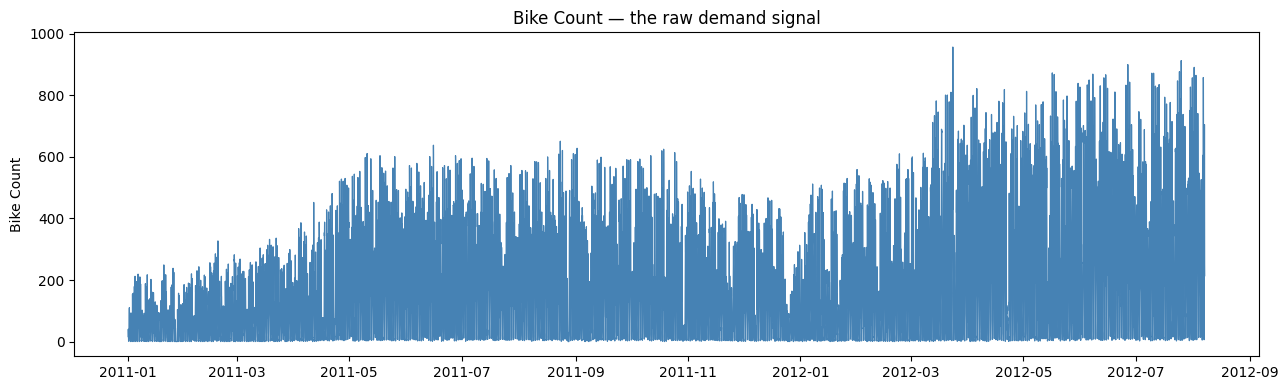

In [52]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hourly.index, hourly.values, color='steelblue', lw=0.9)
ax.set_title('Bike Count — the raw demand signal')
ax.set_ylabel('Bike Count')
plt.tight_layout(); plt.show()

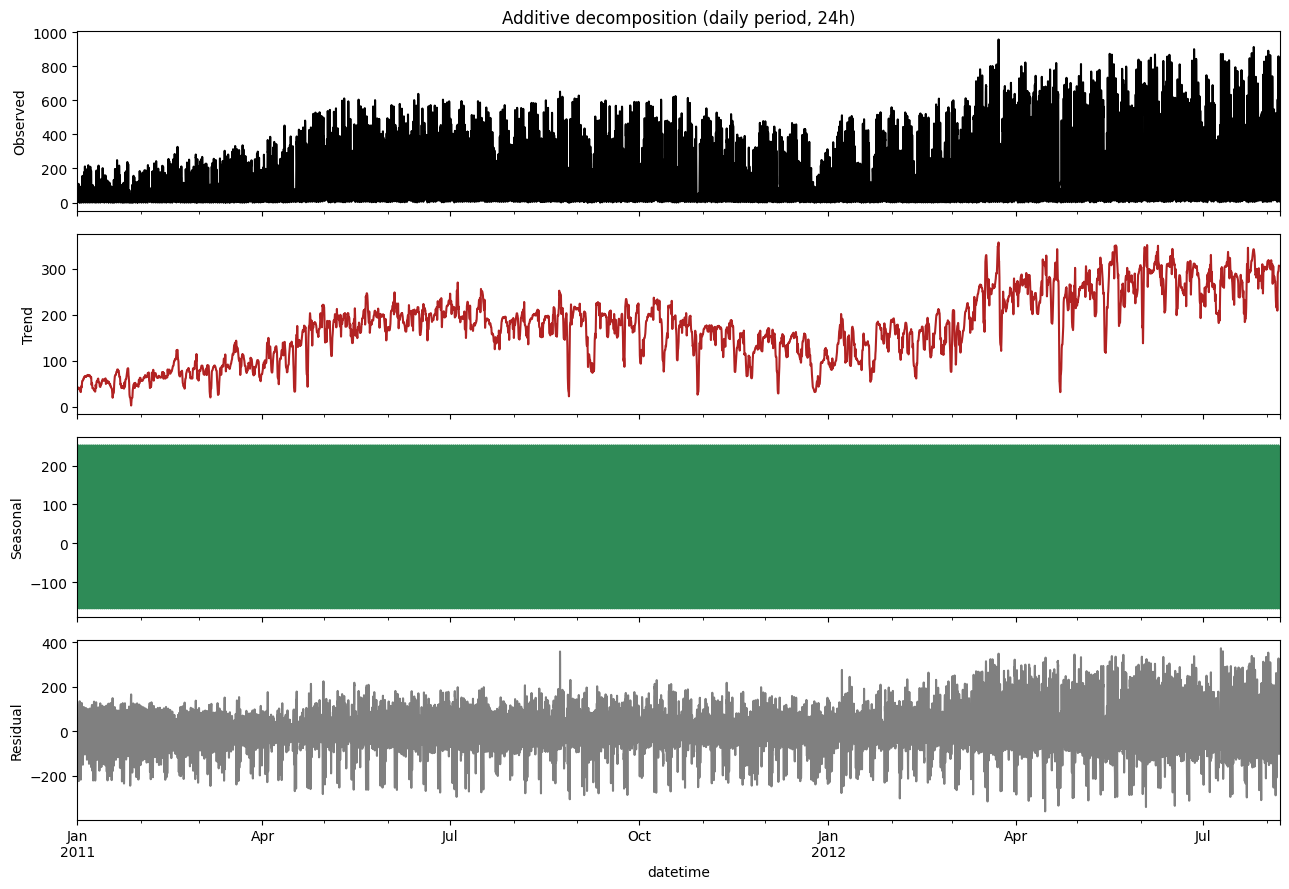

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Daily cycle: one pattern every 24 hours
decomp = seasonal_decompose(hourly, model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="black");    axes[0].set_ylabel("Observed")
decomp.trend.plot(ax=axes[1], color="firebrick");   axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax=axes[2], color="seagreen"); axes[2].set_ylabel("Seasonal")
decomp.resid.plot(ax=axes[3], color="gray");        axes[3].set_ylabel("Residual")
axes[0].set_title("Additive decomposition (daily period, 24h)")
plt.tight_layout()
plt.show()

**Reading the decomposition:**
Demand has a clear upward trend and a strong daily cycle, but residuals are non-constant, so covariates matter for forecasting (which is why SARIMAX must be used).

## Stationarity & ADF test

In [54]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    stat, p, *_ = adfuller(series.dropna())
    verdict = "STATIONARY" if p < 0.05 else "NON-stationary"
    print(f"{name:<28} ADF={stat:7.2f}  p-value={p:.4f}  -> {verdict}")

adf_report(hourly, "Original series")
adf_report(hourly.diff(), "After 1st differencing")

Original series              ADF=  -6.35  p-value=0.0000  -> STATIONARY
After 1st differencing       ADF= -27.42  p-value=0.0000  -> STATIONARY


## Modelling Variance Growth

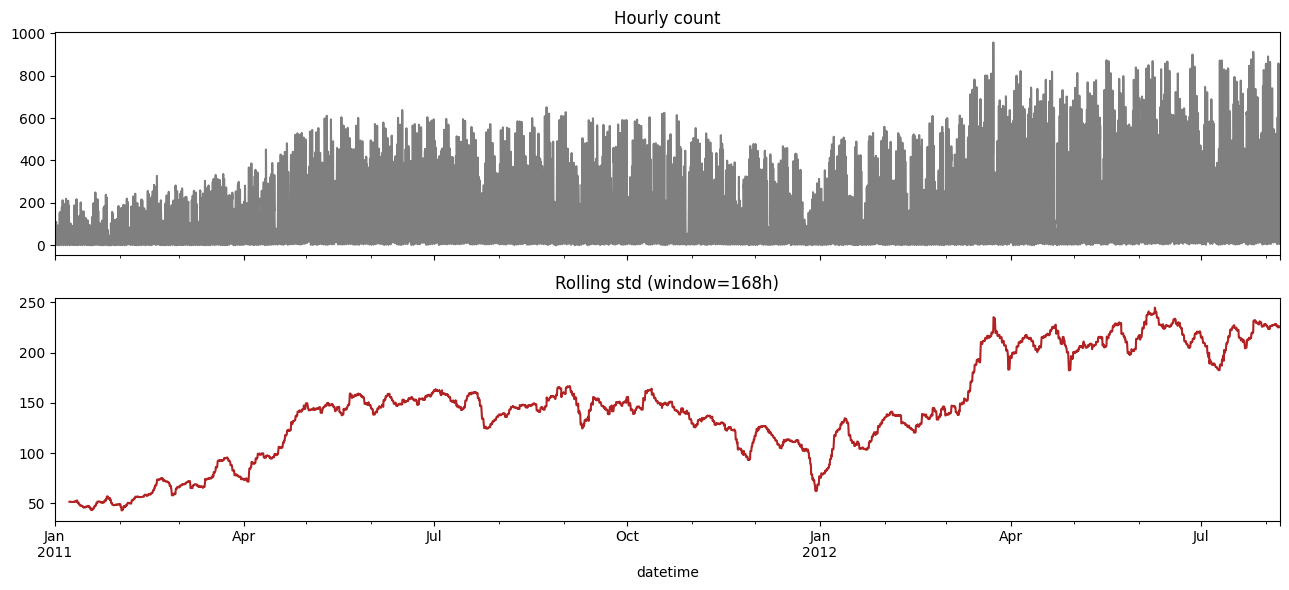

Rolling std early→late: 49.4 → 217.6  (×4.40)


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

win = 24 * 7  # 1 week
roll_mean = hourly.rolling(win).mean()
roll_std = hourly.rolling(win).std()
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
hourly.plot(ax=ax[0], color="black", alpha=0.5, title="Hourly count")
roll_std.plot(ax=ax[1], color="firebrick", title=f"Rolling std (window={win}h)")
plt.tight_layout()
plt.show()
early = roll_std.iloc[win : win + 24 * 30].mean()
late = roll_std.iloc[-24 * 30 :].mean()
print(f"Rolling std early→late: {early:.1f} → {late:.1f}  (×{late/early:.2f})")


Corr(rolling mean, rolling std): 0.985


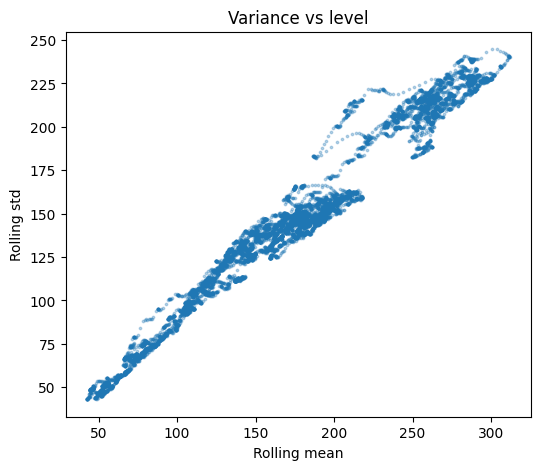

                 mean    std
cnt                         
(-0.001, 7.0]     3.7    2.1
(7.0, 24.0]      15.0    5.0
(24.0, 52.0]     37.0    8.2
(52.0, 89.0]     70.7   10.7
(89.0, 129.0]   109.0   11.7
(129.0, 174.0]  151.7   12.8
(174.0, 224.0]  198.3   14.7
(224.0, 295.0]  257.6   20.8
(295.0, 412.0]  348.8   33.9
(412.0, 957.0]  545.3  109.3
Suggested Box-Cox λ ≈ 0.309  (0 ≈ log, 1 ≈ no transform)
LOG rolling std early→late: 1.595 → 1.368  (×0.86)


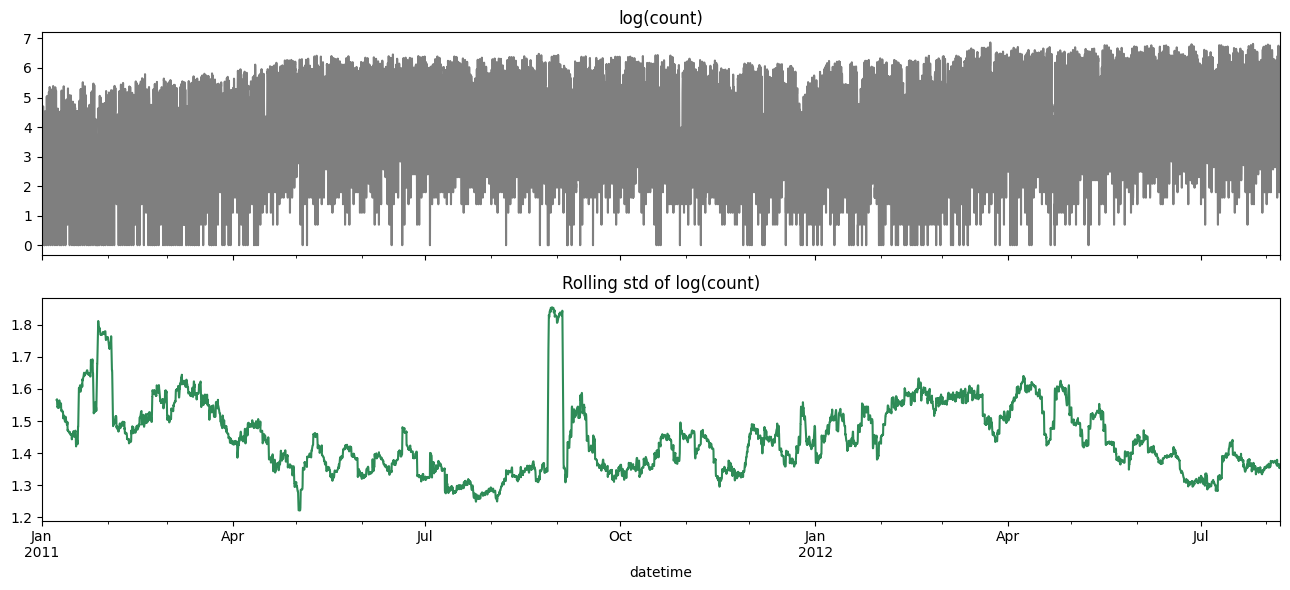

→ LEVEL-SCALING heteroskedasticity detected: prefer Log / Box-Cox


In [56]:
corr_level = roll_mean.corr(roll_std)
print(f"Corr(rolling mean, rolling std): {corr_level:.3f}")
# scatter: local mean vs local std
plt.figure(figsize=(6, 5))
plt.scatter(roll_mean, roll_std, s=3, alpha=0.3)
plt.xlabel("Rolling mean")
plt.ylabel("Rolling std")
plt.title("Variance vs level")
plt.show()
# std by decile of level
decile = pd.qcut(hourly, 10, duplicates="drop")
print(hourly.groupby(decile, observed=True).agg(["mean", "std"]).round(1))
# Box-Cox / log
y = hourly.clip(lower=1).astype(float)  # Box-Cox needs > 0
y_log = np.log(y)
# optional: find Box-Cox lambda
_, lam = stats.boxcox(y)
print(f"Suggested Box-Cox λ ≈ {lam:.3f}  (0 ≈ log, 1 ≈ no transform)")
roll_std_log = y_log.rolling(win).std()
early_l = roll_std_log.iloc[win : win + 24 * 30].mean()
late_l = roll_std_log.iloc[-24 * 30 :].mean()
print(f"LOG rolling std early→late: {early_l:.3f} → {late_l:.3f}  (×{late_l/early_l:.2f})")
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
y_log.plot(ax=ax[0], color="black", alpha=0.5, title="log(count)")
roll_std_log.plot(ax=ax[1], color="seagreen", title="Rolling std of log(count)")
plt.tight_layout()
plt.show()
# Decision print
if corr_level > 0.7 and (late / early) > 1.5:
    print("→ LEVEL-SCALING heteroskedasticity detected: prefer Log / Box-Cox")
else:
    print("→ Level-scaling not dominant; check clustering / hour effects")


In [57]:
# =========================================================
# 3) Clustered volatile patches?  → GARCH on residuals (later)
# =========================================================
abs_diff = hourly.diff().abs().dropna()
print("\nACF of |Δy| (clustering / seasonal vol):")
for lag in [1, 2, 3, 24, 168]:
    print(f"  lag {lag:3d}: {abs_diff.autocorr(lag):.3f}")
# If lag-1 is high BUT lag-24/168 dominate, it's seasonal vol, not GARCH-first
acf1, acf24 = abs_diff.autocorr(1), abs_diff.autocorr(24)
if acf24 > acf1:
    print("→ |Δy| persistence peaks at seasonal lags: hour/week regime > GARCH")
elif acf1 > 0.3:
    print("→ Short-lag |Δy| clustering present: consider GARCH on model residuals")
else:
    print("→ Little evidence of volatility clustering")


ACF of |Δy| (clustering / seasonal vol):
  lag   1: 0.476
  lag   2: 0.337
  lag   3: 0.098
  lag  24: 0.694
  lag 168: 0.793
→ |Δy| persistence peaks at seasonal lags: hour/week regime > GARCH


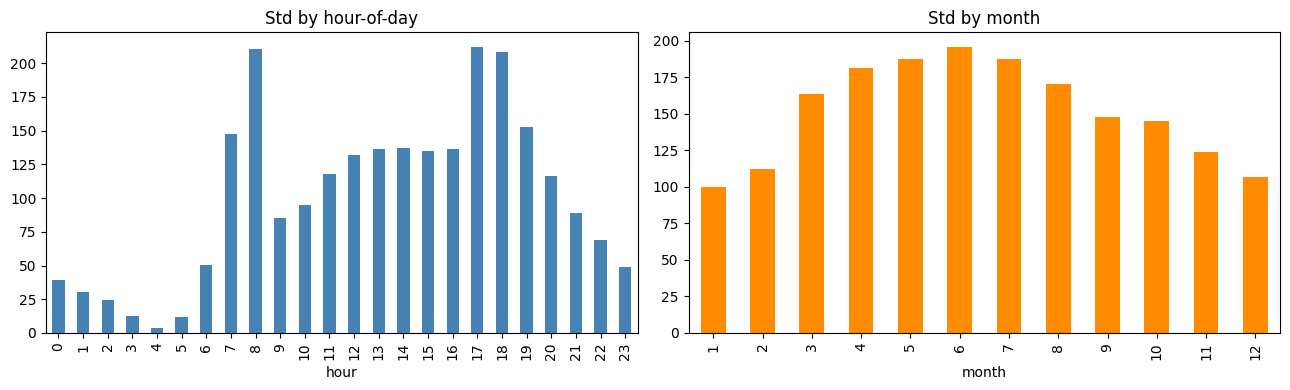

Hour std max/min: 53.1×
→ Strong hour-tied heteroskedasticity: use hour dummies / weighted / regime model
After log — hour std max/min: 2.0×


In [58]:
# =========================================================
# 4) Tied to season / hour?  → weighted or regime model
# =========================================================
by_hour = hourly.groupby(hourly.index.hour).agg(["mean", "std"])
by_month = hourly.groupby(hourly.index.month).agg(["mean", "std"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_hour["std"].plot(kind="bar", ax=ax[0], color="steelblue", title="Std by hour-of-day")
by_month["std"].plot(kind="bar", ax=ax[1], color="darkorange", title="Std by month")
ax[0].set_xlabel("hour")
ax[1].set_xlabel("month")
plt.tight_layout()
plt.show()
hour_ratio = by_hour["std"].max() / by_hour["std"].min()
print(f"Hour std max/min: {hour_ratio:.1f}×")
if hour_ratio > 3:
    print("→ Strong hour-tied heteroskedasticity: use hour dummies / weighted / regime model")
# After log, re-check hour effect
by_hour_log = y_log.groupby(y_log.index.hour).std()
print(f"After log — hour std max/min: {by_hour_log.max()/by_hour_log.min():.1f}×")

### Need Box-Cox transformation (log isn't enough)

Box-Cox λ = 0.3085


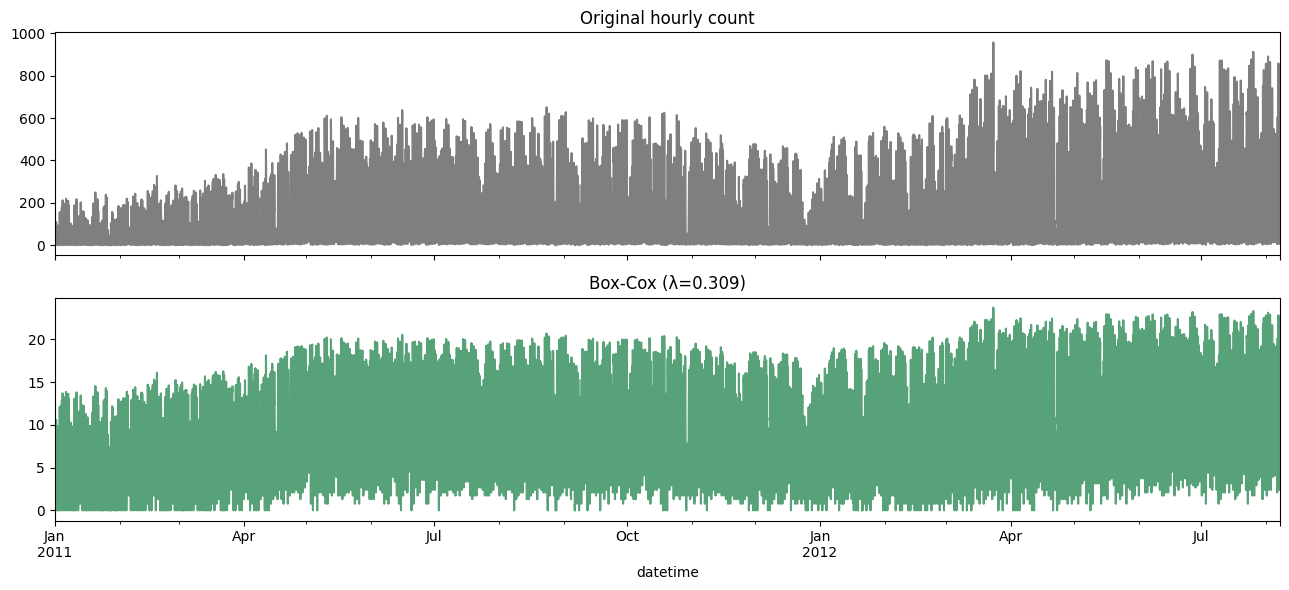

datetime
2011-01-01 00:00:00    4.383246
2011-01-01 01:00:00    6.874189
2011-01-01 02:00:00    6.201224
2011-01-01 03:00:00    3.910126
2011-01-01 04:00:00    0.000000
Freq: h, Name: cnt_boxcox, dtype: float64

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Box-Cox requires strictly positive values
y = hourly.clip(lower=1).astype(float)

y_boxcox, lam = stats.boxcox(y)
hourly_boxcox = pd.Series(y_boxcox, index=hourly.index, name="cnt_boxcox")

print(f"Box-Cox λ = {lam:.4f}")
# λ ≈ 0 → log-like; λ ≈ 1 → almost no transform; your data was near log earlier

# inverse (useful later for forecasts back to count scale)
def inv_boxcox(x, lam):
    if abs(lam) < 1e-8:
        return np.exp(x)
    return np.power(lam * x + 1, 1 / lam)

# quick before/after check
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
hourly.plot(ax=ax[0], color="black", alpha=0.5, title="Original hourly count")
hourly_boxcox.plot(ax=ax[1], color="seagreen", alpha=0.8, title=f"Box-Cox (λ={lam:.3f})")
plt.tight_layout()
plt.show()

hourly_boxcox.head()

/Users/gatikgola/Desktop/Projects/forecasting-rental-bike-count/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gatikgola/Desktop/Projects/forecasting-rental-bike-count/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                11122
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -20495.329
Date:                            Wed, 15 Jul 2026   AIC                          41000.659
Time:                                    15:58:00   BIC                          41037.230
Sample:                                         0   HQIC                         41012.974
                                          - 11122                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7110      0.006    115.847      0.000       0.699       0.723
ma.L1          0.3766      0.009   

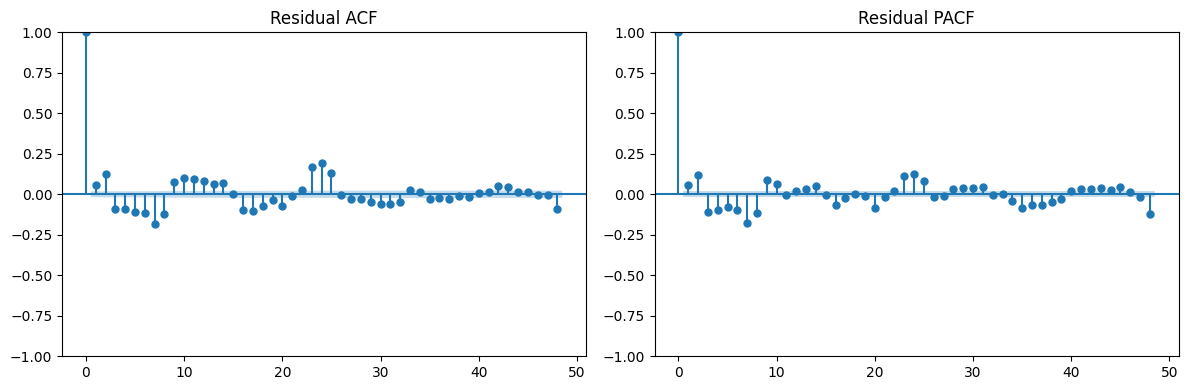


Ljung-Box on residuals (H0: no autocorrelation):
         lb_stat  lb_pvalue
24   2764.428651        0.0
48   3296.899908        0.0
168  8467.972388        0.0
→ Residuals look like white noise? False


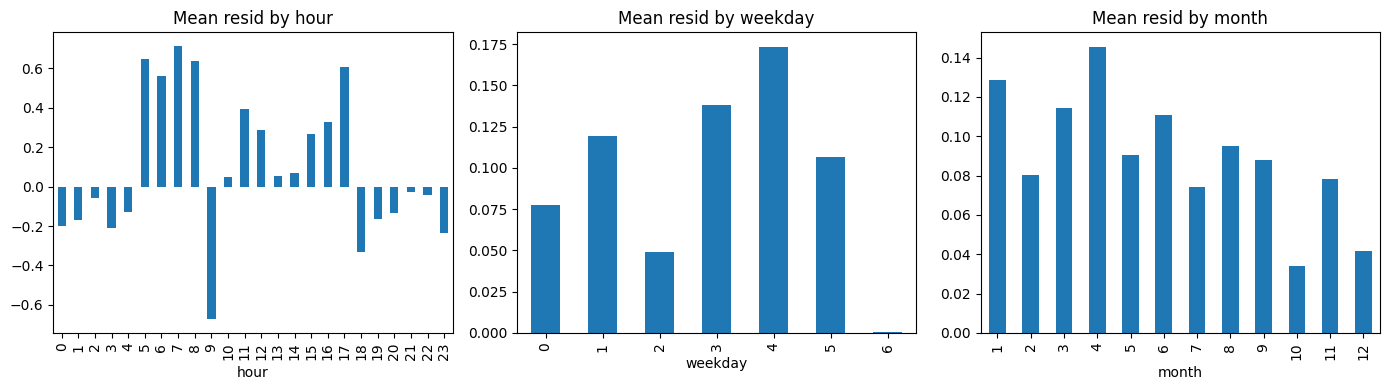

Max |mean resid| by hour:    0.7133
Max |mean resid| by weekday: 0.1735
→ Add calendar dummies (SARIMAX)? True

Corr(resid, weather):
temp          0.018
hum          -0.052
windspeed    -0.016
weathersit   -0.122
dtype: float64
→ Add weather regressors (SARIMAX)? True

→ Fitting SARIMAX with selected regressors...


/Users/gatikgola/Desktop/Projects/forecasting-rental-bike-count/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gatikgola/Desktop/Projects/forecasting-rental-bike-count/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gatikgola/Desktop/Projects/forecasting-rental-bike-count/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                11122
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -18812.167
Date:                            Wed, 15 Jul 2026   AIC                          37702.334
Time:                                    15:59:23   BIC                          37987.593
Sample:                                         0   HQIC                         37798.395
                                          - 11122                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday        0.3481      0.196      1.773      0.076      -0.037       0.733
hour_1        -1.2300      0.093   

/Users/gatikgola/Desktop/Projects/forecasting-rental-bike-count/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


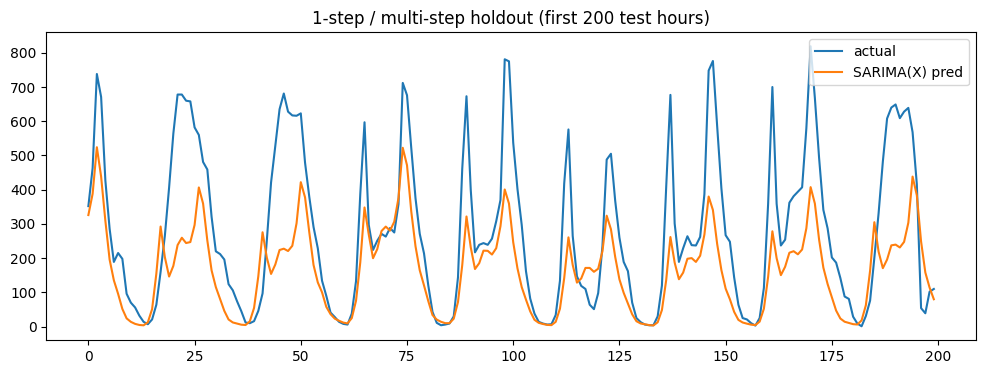

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ============================================================
# 0) Align target + exogenous (use original rows; avoid fillna(0))
# ============================================================
raw = pd.read_parquet("../data/01_raw/bike_data_train.parquet")
raw["datetime"] = pd.to_datetime(raw["datetime"])
raw = raw.sort_values("datetime").set_index("datetime")

y_raw = raw["cnt"].astype(float).clip(lower=1)

# Box-Cox (reuse lam if you already estimated it)
y_bc, lam = stats.boxcox(y_raw.to_numpy())
y = pd.Series(y_bc, index=y_raw.index, name="y")

# Calendar + weather exog on same index
exog_full = pd.DataFrame(index=raw.index)
exog_full["hour"] = raw.index.hour
exog_full["weekday"] = raw["weekday"]
exog_full["holiday"] = raw["holiday"]
exog_full["month"] = raw.index.month
exog_full["temp"] = raw["temp"]
exog_full["hum"] = raw["hum"]
exog_full["windspeed"] = raw["windspeed"]
exog_full["weathersit"] = raw["weathersit"]

# Train / test (chronological)
n = len(y)
cut = int(n * 0.8)
y_train, y_test = y.iloc[:cut], y.iloc[cut:]
exog_train, exog_test = exog_full.iloc[:cut], exog_full.iloc[cut:]

# ============================================================
# 1) Fit baseline SARIMA (no exog)
#    start simple; s=24 for daily seasonality on hourly data
# ============================================================
order = (1, 0, 1)          # (p, d, q)  — ADF suggested d=0
seasonal_order = (1, 0, 1, 24)  # (P, D, Q, s)

sarima = SARIMAX(
    y_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_res = sarima.fit(disp=False)
print(sarima_res.summary())

# In-sample residuals
resid = sarima_res.resid.dropna()

# ============================================================
# 2) Residual diagnostics: white noise?
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, lags=48, ax=ax[0], title="Residual ACF")
plot_pacf(resid, lags=48, ax=ax[1], title="Residual PACF")
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[24, 48, 168], return_df=True)
print("\nLjung-Box on residuals (H0: no autocorrelation):")
print(lb)

def is_white_noise(lb_df, alpha=0.05):
    return (lb_df["lb_pvalue"] > alpha).all()

wn = is_white_noise(lb)
print("→ Residuals look like white noise?" , wn)

# ============================================================
# 3) Residuals show calendar patterns? → calendar dummies
# ============================================================
resid_df = pd.DataFrame({"resid": resid})
resid_df["hour"] = resid_df.index.hour
resid_df["weekday"] = resid_df.index.weekday
resid_df["month"] = resid_df.index.month

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
resid_df.groupby("hour")["resid"].mean().plot(kind="bar", ax=ax[0], title="Mean resid by hour")
resid_df.groupby("weekday")["resid"].mean().plot(kind="bar", ax=ax[1], title="Mean resid by weekday")
resid_df.groupby("month")["resid"].mean().plot(kind="bar", ax=ax[2], title="Mean resid by month")
plt.tight_layout()
plt.show()

# magnitude of calendar leftover
hour_amp = resid_df.groupby("hour")["resid"].mean().abs().max()
weekday_amp = resid_df.groupby("weekday")["resid"].mean().abs().max()
print(f"Max |mean resid| by hour:    {hour_amp:.4f}")
print(f"Max |mean resid| by weekday: {weekday_amp:.4f}")

need_calendar = (hour_amp > 0.05) or (weekday_amp > 0.05)  # threshold on Box-Cox scale; tune visually
print("→ Add calendar dummies (SARIMAX)?", need_calendar)

# ============================================================
# 4) Residuals correlate with weather? → weather regressors
# ============================================================
weather_cols = ["temp", "hum", "windspeed", "weathersit"]
weather_aligned = exog_train.loc[resid.index, weather_cols]
weather_corr = weather_aligned.apply(lambda c: resid.corr(c))
print("\nCorr(resid, weather):")
print(weather_corr.round(3))

need_weather = weather_corr.abs().max() > 0.05
print("→ Add weather regressors (SARIMAX)?", need_weather)

# ============================================================
# 5) Build SARIMAX if needed
# ============================================================
def make_calendar_dummies(df):
    out = pd.get_dummies(df[["hour", "weekday", "holiday"]].astype(int),
                         columns=["hour", "weekday"], drop_first=True)
    return out.astype(float)

calendar_train = make_calendar_dummies(exog_train)
calendar_test = make_calendar_dummies(exog_test)

weather_train = exog_train[weather_cols].astype(float)
weather_test = exog_test[weather_cols].astype(float)

exog_parts = []
if need_calendar:
    exog_parts.append(calendar_train)
if need_weather:
    exog_parts.append(weather_train)

if wn and not need_calendar and not need_weather:
    print("\n→ SARIMA is sufficient; stop here.")
    final_res = sarima_res
    final_exog_test = None
else:
    print("\n→ Fitting SARIMAX with selected regressors...")
    exog_tr = pd.concat(exog_parts, axis=1) if exog_parts else None
    # match test columns
    if exog_tr is not None:
        parts_te = []
        if need_calendar:
            parts_te.append(calendar_test)
        if need_weather:
            parts_te.append(weather_test)
        exog_te = pd.concat(parts_te, axis=1)
        exog_te = exog_te.reindex(columns=exog_tr.columns, fill_value=0.0)
    else:
        exog_te = None

    sarimax = SARIMAX(
        y_train,
        exog=exog_tr,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    final_res = sarimax.fit(disp=False)
    final_exog_test = exog_te
    print(final_res.summary())

    # re-check residuals
    resid2 = final_res.resid.dropna()
    lb2 = acorr_ljungbox(resid2, lags=[24, 48, 168], return_df=True)
    print("\nLjung-Box after SARIMAX:")
    print(lb2)

# ============================================================
# 6) Forecast on test set (Box-Cox scale → count scale)
# ============================================================
def inv_boxcox(x, lam):
    x = np.asarray(x)
    if abs(lam) < 1e-8:
        return np.exp(x)
    return np.power(np.maximum(lam * x + 1, 1e-8), 1.0 / lam)

fc = final_res.get_forecast(steps=len(y_test), exog=final_exog_test)
pred_bc = fc.predicted_mean
pred_cnt = pd.Series(inv_boxcox(pred_bc, lam), index=y_test.index, name="pred")
actual_cnt = y_raw.loc[y_test.index]

mae = np.mean(np.abs(actual_cnt - pred_cnt))
rmse = np.sqrt(np.mean((actual_cnt - pred_cnt) ** 2))
mape = np.mean(np.abs((actual_cnt - pred_cnt) / actual_cnt.clip(lower=1))) * 100
print(f"\nTest MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

nplot = 200
plt.figure(figsize=(12, 4))
plt.plot(actual_cnt.values[:nplot], label="actual")
plt.plot(pred_cnt.values[:nplot], label="SARIMA(X) pred")
plt.legend()
plt.title("1-step / multi-step holdout (first 200 test hours)")
plt.show()

# Conclusions

- The Baseline Gradient Boosting Model gives quite a poor performance
- Adding the target lags and feature lags improved the model significantly,
- For the baseline production pipeline, we will use the parameters we found in training
- Potential improvement is to use Hyperparameter Tuning with Optuna.